/var/folders/3m/8g78_lsx19g84nyrw2_0ccfr0000gn/T/ipykernel_4356/2664625040.py:5: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "bool"):


  0%|          | 0/200 [00:00<?, ?it/s]

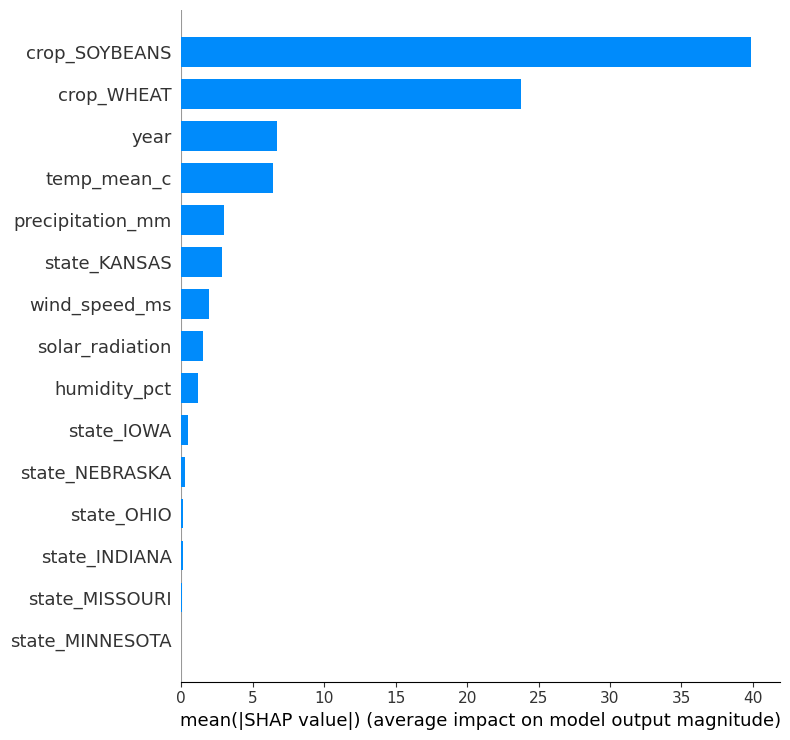

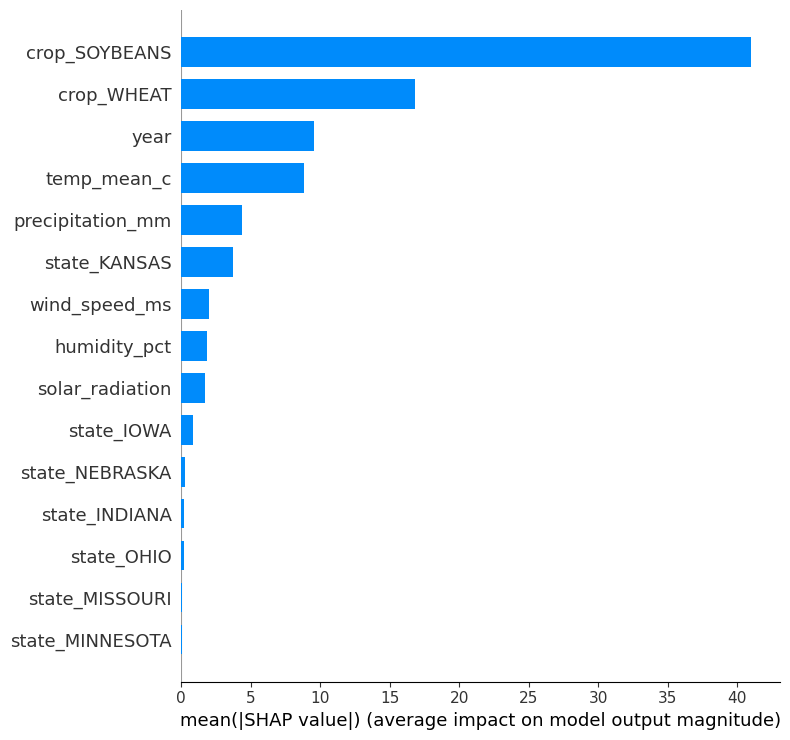

  0%|          | 0/1 [00:00<?, ?it/s]

AttributeError: 'numpy.ndarray' object has no attribute 'base_values'

In [1]:
# --- 1. Imports and Compatibility Patch ---
import numpy as np

# Compatibility patches for SHAP with NumPy >=1.24
if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "int"):
    np.int = int

import pandas as pd
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

# --- 2. Load dataset ---
df = pd.read_csv("../data/processed/climate_yield_merged.csv")

# --- 3. One-hot encode categorical features ---
X = pd.get_dummies(
    df[["crop","state","year","temp_mean_c","precipitation_mm",
        "humidity_pct","solar_radiation","wind_speed_ms"]],
    drop_first=True
)
y = df["yield_bu_acre"]

# --- 4. Train XGBoost model ---
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X, y)

# --- 5. SHAP Explainer (KernelExplainer avoids booster decoding bug) ---
f = lambda data: xgb_model.predict(data)
background = X.sample(min(100, len(X)), random_state=42)   # safe background sample
explainer = shap.KernelExplainer(f, background)

# For speed, explain a subset (safe sample size)
X_sample = X.sample(min(200, len(X)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# --- 6. Global Feature Importance (bar plot avoids colorbar error) ---
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# --- 7. Per-Crop Analysis (example: CORN, bar plot) ---
corn_idx = df.loc[X_sample.index, "crop"] == "CORN"
shap.summary_plot(shap_values[corn_idx], X_sample[corn_idx], plot_type="bar")

# --- 8. Single Prediction Explanation ---
sample = X_sample.iloc[[0]]
shap.plots.waterfall(explainer.shap_values(sample)[0])

# --- 9. Export SHAP values to CSV ---
shap_df = pd.DataFrame(shap_values, columns=X_sample.columns, index=X_sample.index)
shap_df["crop"] = df.loc[X_sample.index, "crop"]
shap_df["state"] = df.loc[X_sample.index, "state"]
shap_df["year"] = df.loc[X_sample.index, "year"]

# Average SHAP impact per crop
avg_shap_by_crop = shap_df.groupby("crop").mean()
avg_shap_by_crop.to_csv("../results/shap_by_crop.csv")

# Average SHAP impact per state
avg_shap_by_state = shap_df.groupby("state").mean()
avg_shap_by_state.to_csv("../results/shap_by_state.csv")

# Top 5 features per crop
top_features_by_crop = (
    shap_df.groupby("crop")[X_sample.columns]
    .mean()
    .abs()
    .apply(lambda row: row.sort_values(ascending=False).head(5), axis=1)
)
top_features_by_crop.to_csv("../results/top_features_by_crop.csv")

# --- 10. Per-Year Analysis ---
avg_shap_by_year = shap_df.groupby("year").mean()
avg_shap_by_year.to_csv("../results/shap_by_year.csv")

for feature in ["temp_mean_c", "precipitation_mm", "humidity_pct", "solar_radiation", "wind_speed_ms"]:
    plt.figure(figsize=(8,4))
    avg_shap_by_year[feature].plot(marker="o", title=f"SHAP impact of {feature} over years")
    plt.ylabel("Average SHAP value")
    plt.xlabel("Year")
    plt.grid(True)
    plt.savefig(f"../results/shap_trend_{feature}.png")
    plt.close()

# --- 11. Per-Year Per-Crop Trends ---
avg_shap_by_crop_year = shap_df.groupby(["crop","year"]).mean()
avg_shap_by_crop_year.to_csv("../results/shap_by_crop_year.csv")

for crop in shap_df["crop"].unique():
    crop_trend = avg_shap_by_crop_year.loc[crop]
    for feature in ["temp_mean_c", "precipitation_mm", "humidity_pct", "solar_radiation", "wind_speed_ms"]:
        plt.figure(figsize=(8,4))
        crop_trend[feature].plot(marker="o", title=f"{crop}: SHAP impact of {feature} over years")
        plt.ylabel("Average SHAP value")
        plt.xlabel("Year")
        plt.grid(True)
        plt.savefig(f"../results/shap_trend_{feature}_{crop}.png")
        plt.close()


  0%|          | 0/200 [00:00<?, ?it/s]

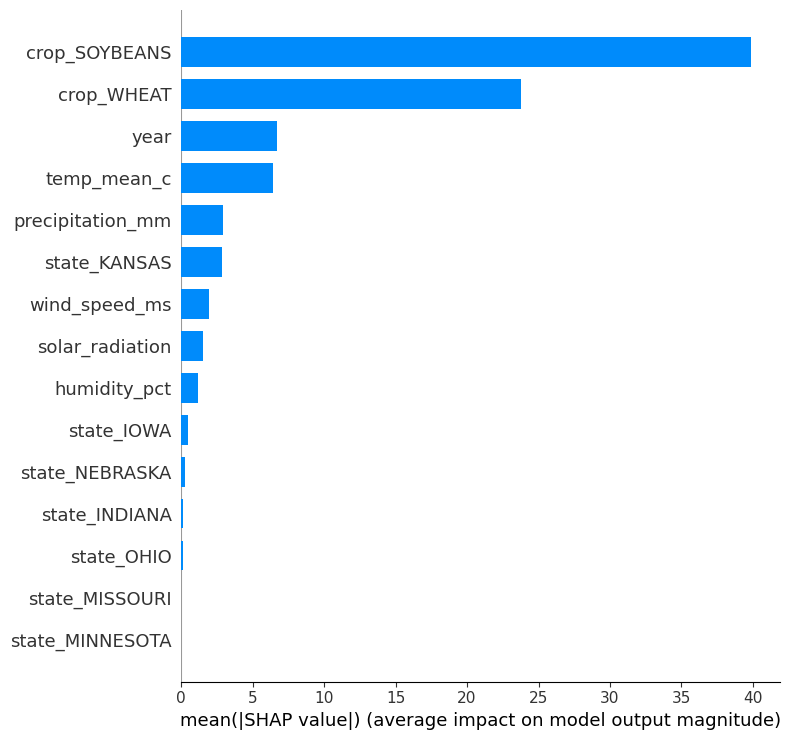

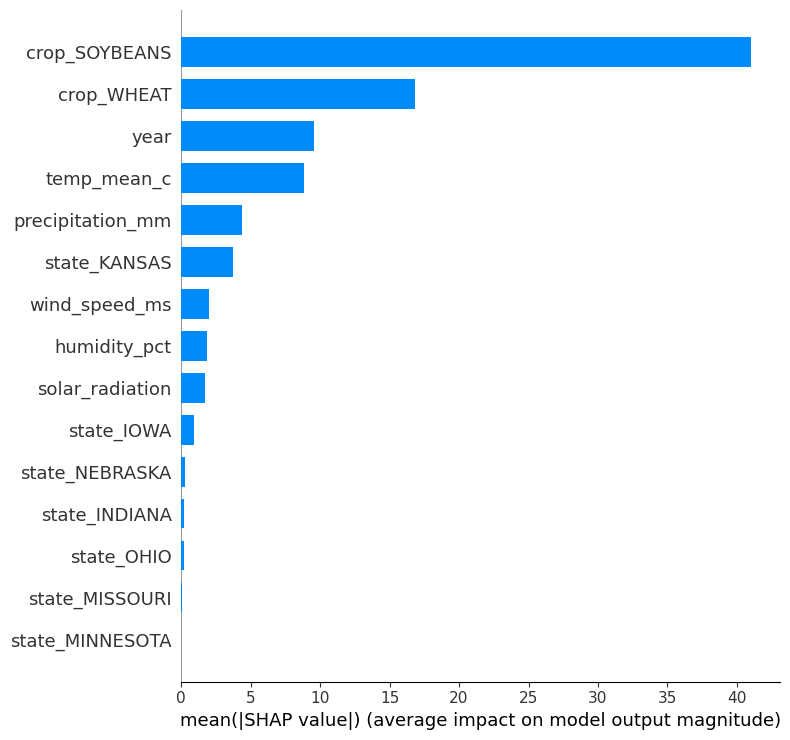

  0%|          | 0/1 [00:00<?, ?it/s]

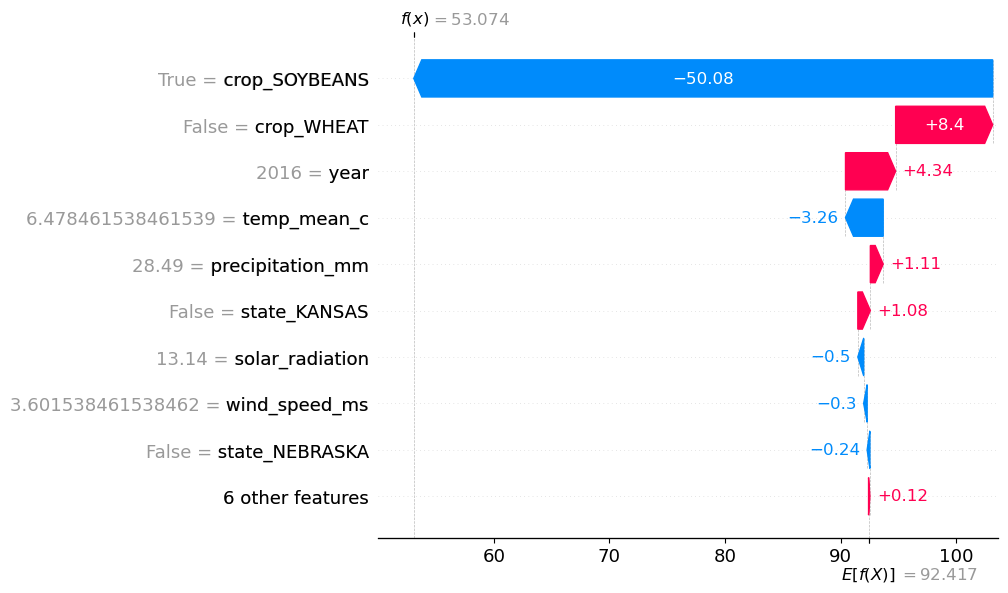

In [4]:
# --- 1. Imports and Compatibility Patch ---
import numpy as np

# Compatibility patches for SHAP with NumPy >=1.24
if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "int"):
    np.int = int

import pandas as pd
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

# --- 2. Load dataset ---
df = pd.read_csv("../data/processed/climate_yield_merged.csv")

# --- 3. One-hot encode categorical features ---
X = pd.get_dummies(
    df[["crop","state","year","temp_mean_c","precipitation_mm",
        "humidity_pct","solar_radiation","wind_speed_ms"]],
    drop_first=True
)
y = df["yield_bu_acre"]

# --- 4. Train XGBoost model ---
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X, y)

# --- 5. SHAP Explainer (KernelExplainer avoids booster decoding bug) ---
f = lambda data: xgb_model.predict(data)
background = X.sample(min(100, len(X)), random_state=42)
explainer = shap.KernelExplainer(f, background)

# For speed, explain a subset
X_sample = X.sample(min(200, len(X)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# --- 6. Global Feature Importance ---
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# --- 7. Per-Crop Analysis (example: CORN) ---
corn_idx = df.loc[X_sample.index, "crop"] == "CORN"
shap.summary_plot(shap_values[corn_idx], X_sample[corn_idx], plot_type="bar")

# --- 8. Single Prediction Explanation ---
sample = X_sample.iloc[[0]]
shap_val_single = explainer.shap_values(sample)[0]

# Cast feature values to strings to avoid bool+str errors
feature_values = sample.astype(str).values[0]

shap_exp = shap.Explanation(
    values=shap_val_single,
    base_values=explainer.expected_value,
    data=feature_values,
    feature_names=sample.columns
)

shap.plots.waterfall(shap_exp)

# --- 9. Export SHAP values to CSV ---
shap_df = pd.DataFrame(shap_values, columns=X_sample.columns, index=X_sample.index)
shap_df["crop"] = df.loc[X_sample.index, "crop"]
shap_df["state"] = df.loc[X_sample.index, "state"]
shap_df["year"] = df.loc[X_sample.index, "year"]

# Select only numeric columns for aggregation
numeric_cols = shap_df.select_dtypes(include=[np.number]).columns

# Average SHAP impact per crop
avg_shap_by_crop = shap_df.groupby("crop")[numeric_cols].mean()
avg_shap_by_crop.to_csv("../results/shap_by_crop.csv")

# Average SHAP impact per state
avg_shap_by_state = shap_df.groupby("state")[numeric_cols].mean()
avg_shap_by_state.to_csv("../results/shap_by_state.csv")

# Top 5 features per crop
top_features_by_crop = (
    shap_df.groupby("crop")[numeric_cols]
    .mean()
    .abs()
    .apply(lambda row: row.sort_values(ascending=False).head(5), axis=1)
)
top_features_by_crop.to_csv("../results/top_features_by_crop.csv")

# --- 10. Per-Year Analysis ---
avg_shap_by_year = shap_df.groupby("year")[numeric_cols].mean()
avg_shap_by_year.to_csv("../results/shap_by_year.csv")

for feature in ["temp_mean_c", "precipitation_mm", "humidity_pct", "solar_radiation", "wind_speed_ms"]:
    plt.figure(figsize=(8,4))
    avg_shap_by_year[feature].plot(marker="o", title=f"SHAP impact of {feature} over years")
    plt.ylabel("Average SHAP value")
    plt.xlabel("Year")
    plt.grid(True)
    plt.savefig(f"../results/shap_trend_{feature}.png")
    plt.close()

# --- 11. Per-Year Per-Crop Trends ---
avg_shap_by_crop_year = shap_df.groupby(["crop","year"])[numeric_cols].mean()
avg_shap_by_crop_year.to_csv("../results/shap_by_crop_year.csv")

for crop in shap_df["crop"].unique():
    crop_trend = avg_shap_by_crop_year.loc[crop]
    for feature in ["temp_mean_c", "precipitation_mm", "humidity_pct", "solar_radiation", "wind_speed_ms"]:
        plt.figure(figsize=(8,4))
        crop_trend[feature].plot(marker="o", title=f"{crop}: SHAP impact of {feature} over years")
        plt.ylabel("Average SHAP value")
        plt.xlabel("Year")
        plt.grid(True)
        plt.savefig(f"../results/shap_trend_{feature}_{crop}.png")
        plt.close()


  0%|          | 0/200 [00:00<?, ?it/s]

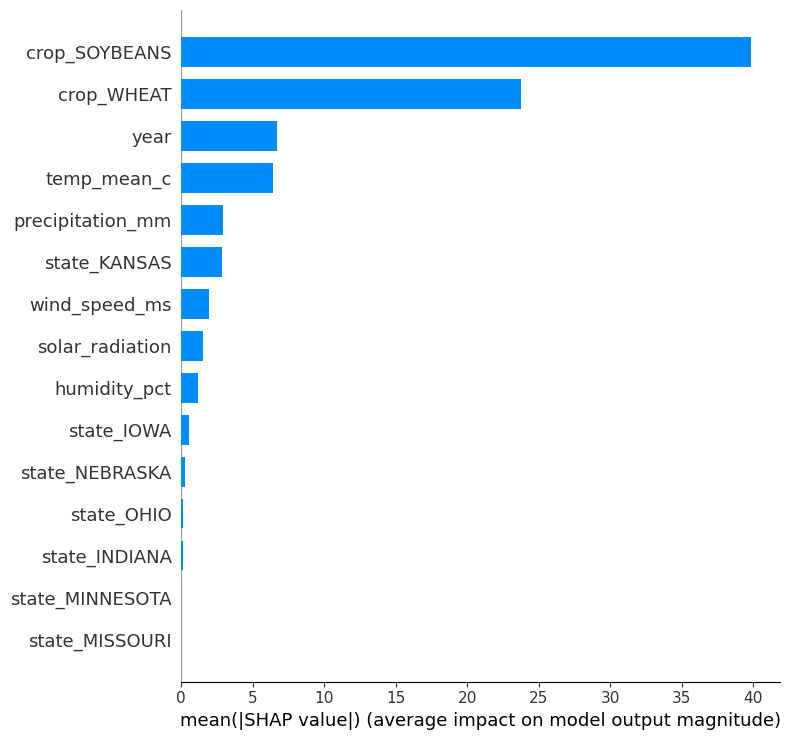

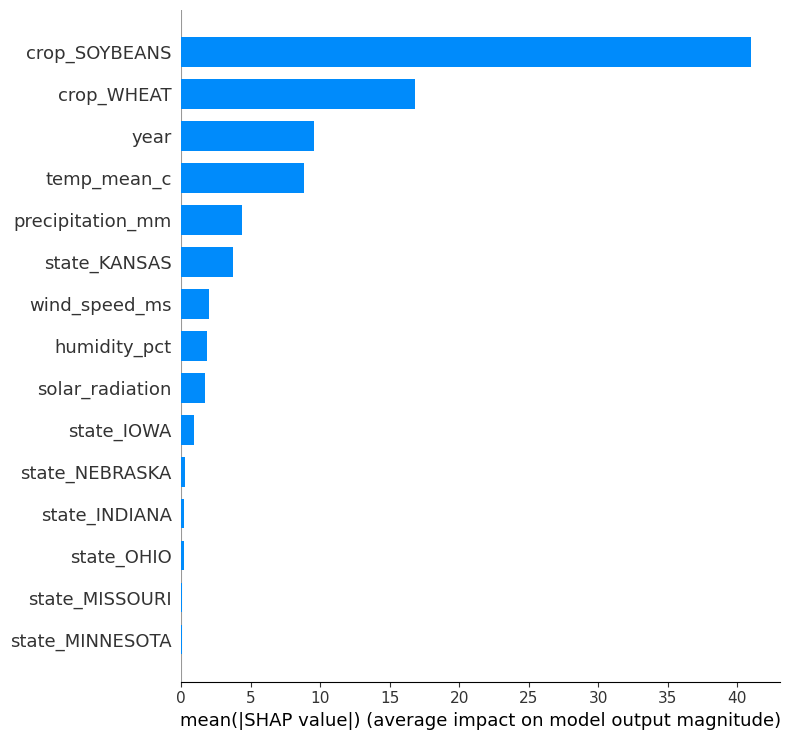

  0%|          | 0/1 [00:00<?, ?it/s]

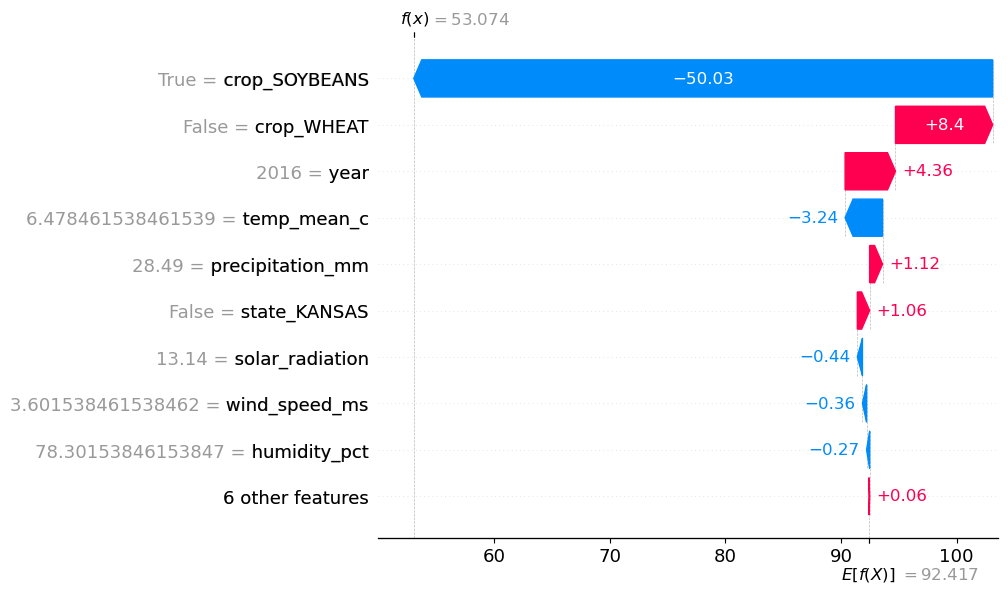

In [5]:
# --- 1. Imports and Compatibility Patch ---
import numpy as np

# Compatibility patches for SHAP with NumPy >=1.24
if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "int"):
    np.int = int

import pandas as pd
import shap
import matplotlib.pyplot as plt
import xgboost as xgb

# --- 2. Load dataset ---
df = pd.read_csv("../data/processed/climate_yield_merged.csv")

# --- 3. One-hot encode categorical features ---
X = pd.get_dummies(
    df[["crop","state","year","temp_mean_c","precipitation_mm",
        "humidity_pct","solar_radiation","wind_speed_ms"]],
    drop_first=True
)
y = df["yield_bu_acre"]

# --- 4. Train XGBoost model ---
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X, y)

# --- 5. SHAP Explainer (KernelExplainer avoids booster decoding bug) ---
f = lambda data: xgb_model.predict(data)
background = X.sample(min(100, len(X)), random_state=42)
explainer = shap.KernelExplainer(f, background)

# For speed, explain a subset
X_sample = X.sample(min(200, len(X)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# --- 6. Global Feature Importance ---
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# --- 7. Per-Crop Analysis (example: CORN) ---
corn_idx = df.loc[X_sample.index, "crop"] == "CORN"
shap.summary_plot(shap_values[corn_idx], X_sample[corn_idx], plot_type="bar")

# --- 8. Single Prediction Explanation ---
sample = X_sample.iloc[[0]]
shap_val_single = explainer.shap_values(sample)[0]

# Cast feature values to strings to avoid bool+str errors
feature_values = sample.astype(str).values[0]

shap_exp = shap.Explanation(
    values=shap_val_single,
    base_values=explainer.expected_value,
    data=feature_values,
    feature_names=sample.columns
)

shap.plots.waterfall(shap_exp)

# --- 9. Export SHAP values to CSV ---
shap_df = pd.DataFrame(shap_values, columns=X_sample.columns, index=X_sample.index)
shap_df["crop"] = df.loc[X_sample.index, "crop"]
shap_df["state"] = df.loc[X_sample.index, "state"]
shap_df["year"] = df.loc[X_sample.index, "year"]

# Select only numeric columns for aggregation
numeric_cols = shap_df.select_dtypes(include=[np.number]).columns

# Average SHAP impact per crop
avg_shap_by_crop = shap_df.groupby("crop")[numeric_cols].mean()
avg_shap_by_crop.to_csv("../results/shap_by_crop.csv")

# Average SHAP impact per state
avg_shap_by_state = shap_df.groupby("state")[numeric_cols].mean()
avg_shap_by_state.to_csv("../results/shap_by_state.csv")

# Top 5 features per crop
top_features_by_crop = (
    shap_df.groupby("crop")[numeric_cols]
    .mean()
    .abs()
    .apply(lambda row: row.sort_values(ascending=False).head(5), axis=1)
)
top_features_by_crop.to_csv("../results/top_features_by_crop.csv")

# --- 10. Per-Year Analysis ---
avg_shap_by_year = shap_df.groupby("year")[numeric_cols].mean()
avg_shap_by_year.to_csv("../results/shap_by_year.csv")

for feature in ["temp_mean_c", "precipitation_mm", "humidity_pct", "solar_radiation", "wind_speed_ms"]:
    plt.figure(figsize=(8,4))
    avg_shap_by_year[feature].plot(marker="o", title=f"SHAP impact of {feature} over years")
    plt.ylabel("Average SHAP value")
    plt.xlabel("Year")
    plt.grid(True)
    plt.savefig(f"../results/shap_trend_{feature}.png")
    plt.close()

# --- 11. Per-Year Per-Crop Trends ---
avg_shap_by_crop_year = shap_df.groupby(["crop","year"])[numeric_cols].mean()
avg_shap_by_crop_year.to_csv("../results/shap_by_crop_year.csv")

for crop in shap_df["crop"].unique():
    crop_trend = avg_shap_by_crop_year.loc[crop]
    for feature in ["temp_mean_c", "precipitation_mm", "humidity_pct", "solar_radiation", "wind_speed_ms"]:
        plt.figure(figsize=(8,4))
        crop_trend[feature].plot(marker="o", title=f"{crop}: SHAP impact of {feature} over years")
        plt.ylabel("Average SHAP value")
        plt.xlabel("Year")
        plt.grid(True)
        plt.savefig(f"../results/shap_trend_{feature}_{crop}.png")
        plt.close()


In [7]:
# --- 12. Dependence Plots for Top Features per Crop ---
for crop in shap_df["crop"].unique():
    # Get top 5 features for this crop
    top_feats = (
        shap_df[shap_df["crop"] == crop][numeric_cols]
        .mean()
        .abs()
        .sort_values(ascending=False)
        .head(5)
        .index
    )
    
    # Subset data for this crop
    crop_idx = shap_df["crop"] == crop
    shap_vals_crop = shap_values[crop_idx]
    X_crop = X_sample.loc[crop_idx]
    
    # Generate dependence plots for each top feature
    for feat in top_feats:
        shap.dependence_plot(
            feat,
            shap_vals_crop,
            X_crop,
            interaction_index=None,
            show=False
        )
        plt.title(f"{crop}: SHAP dependence for {feat}")
        plt.savefig(f"../results/shap_dependence_{feat}_{crop}.png")
        plt.close()


In [9]:
# --- 13. Interaction Dependence Plots ---
# Example pairs: precipitation vs temp, humidity vs solar radiation, wind vs temp
import numpy as np

# Compatibility patches for SHAP with NumPy >=1.24
if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "int"):
    np.int = int
if not hasattr(np, "float"):
    np.float = float

interaction_pairs = [
    ("precipitation_mm", "temp_mean_c"),
    ("humidity_pct", "solar_radiation"),
    ("wind_speed_ms", "temp_mean_c")
]

for crop in shap_df["crop"].unique():
    crop_idx = shap_df["crop"] == crop
    shap_vals_crop = shap_values[crop_idx]
    X_crop = X_sample.loc[crop_idx]
    
    for feat, inter in interaction_pairs:
        shap.dependence_plot(
            feat,
            shap_vals_crop,
            X_crop,
            interaction_index=inter,
            show=False
        )
        plt.title(f"{crop}: SHAP dependence {feat} vs {inter}")
        plt.savefig(f"../results/shap_dependence_{feat}_vs_{inter}_{crop}.png")
        plt.close()


In [10]:
# --- 14. Correlation of SHAP values between features ---
shap_corr = pd.DataFrame(shap_values, columns=X_sample.columns).corr()

# Save correlation matrix
shap_corr.to_csv("../results/shap_feature_correlation.csv")

# Plot heatmap
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(shap_corr, cmap="coolwarm", center=0)
plt.title("Correlation of SHAP values between features")
plt.savefig("../results/shap_feature_correlation_heatmap.png")
plt.close()


In [11]:
import seaborn as sns

shap_corr = pd.DataFrame(shap_values, columns=X_sample.columns).corr()
shap_corr.to_csv("../results/shap_feature_correlation.csv")

plt.figure(figsize=(10,8))
sns.heatmap(shap_corr, cmap="coolwarm", center=0)
plt.title("Correlation of SHAP values between features")
plt.savefig("../results/shap_feature_correlation_heatmap.png")
plt.close()


In [12]:
from itertools import combinations

interaction_strengths = []
shap_df_numeric = pd.DataFrame(shap_values, columns=X_sample.columns)

for f1, f2 in combinations(X_sample.columns, 2):
    corr = shap_df_numeric[f1].corr(shap_df_numeric[f2])
    interaction_strengths.append((f1, f2, abs(corr)))

interaction_strengths = sorted(interaction_strengths, key=lambda x: x[2], reverse=True)
pd.DataFrame(interaction_strengths, columns=["Feature1","Feature2","AbsCorrelation"])\
    .to_csv("../results/shap_interaction_strengths.csv", index=False)


In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# Load the interaction strengths we already computed
interaction_df = pd.read_csv("../results/shap_interaction_strengths.csv")

# Build graph: nodes = features, edges = correlation strength
G = nx.Graph()

for _, row in interaction_df.iterrows():
    f1, f2, strength = row["Feature1"], row["Feature2"], row["AbsCorrelation"]
    # Add edge only if correlation is strong enough (e.g., > 0.3)
    if strength > 0.3:
        G.add_edge(f1, f2, weight=strength)

# Draw graph
plt.figure(figsize=(12,10))
pos = nx.spring_layout(G, k=0.3, seed=42)  # layout for clarity
edges = G.edges(data=True)

nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="lightblue")
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, width=[d["weight"]*5 for (_,_,d) in edges], alpha=0.6)

plt.title("Feature Interaction Network (SHAP correlations > 0.3)")
plt.axis("off")
plt.savefig("../results/shap_feature_interaction_network.png")
plt.close()
